# Часть 2. `(L0, L1)`-гладкость, clipping и адаптивные методы в задаче обучения

Этот notebook является самостоятельной второй частью проекта. В нем сначала выписана теория, затем реализованы методы оптимизации и тесты, а после этого проведен эксперимент на задаче бинарной классификации `make_moons`.

Рассматриваем обучение нейронной сети как задачу

$$
\min_{\theta \in \mathbb{R}^d} F(\theta),
\qquad
F(\theta)=\frac{1}{n}\sum_{i=1}^n \ell(f_\theta(x_i),y_i).
$$

В первой части проекта сравнивались BCE и MSE. Здесь фиксируем BCE и сравниваем уже методы оптимизации:

- обычный full-batch GD;
- clipped GD;
- normalized GD;
- NSGD-M;
- GD с backtracking line search;
- шаг Поляка.

Дополнительно считаем локальную оценку гладкости

$$
\hat L_k =
\frac{\|g_k-g_{k-1}\|}
{\|x_k-x_{k-1}\|+\epsilon_{\mathrm{num}}},
$$

и проверяем, коррелирует ли она с $\|g_k\|$, как предполагает модель `(L0, L1)`-гладкости.

## 1. Постановка задачи обучения

Обучение нейронной сети можно рассматривать как минимизацию empirical risk по параметрам модели:

$$
\min_{\theta \in \mathbb{R}^d} F(\theta),
\qquad
F(\theta)=\frac{1}{n}\sum_{i=1}^n \ell(f_\theta(x_i), y_i)+r(\theta).
$$

Здесь $\theta$ - вектор всех весов и bias сети, $f_\theta(x)$ - предсказание модели, $\ell$ - функция потерь, $r(\theta)$ - возможная регуляризация.

Для бинарной классификации сеть выдает логит

$$
z_\theta(x)\in\mathbb{R},
\qquad
p_\theta(x)=\sigma(z_\theta(x))=\frac{1}{1+\exp(-z_\theta(x))}.
$$

Для BCE:

$$
\ell_{\mathrm{BCE}}(p,y)=-y\log p-(1-y)\log(1-p),
$$

и после совмещения sigmoid с BCE:

$$
\frac{\partial \ell_{\mathrm{BCE}}}{\partial z}=p-y.
$$

Для MSE по вероятности:

$$
\ell_{\mathrm{MSE}}(p,y)=(p-y)^2,
$$

$$
\frac{\partial \ell_{\mathrm{MSE}}}{\partial z}=2(p-y)p(1-p).
$$

Множитель $p(1-p)$ объясняет, почему MSE может давать слабый градиент при насыщенной sigmoid. В этой части проекта фиксируем BCE как основную loss-функцию и исследуем уже не выбор loss, а выбор метода оптимизации.

## 2. Классическая гладкость и `(L0, L1)`-гладкость

Классическая `L`-гладкость требует

$$
\|\nabla^2 F(x)\| \le L.
$$

Эквивалентно, градиент является липшицевым:

$$
\|\nabla F(x)-\nabla F(y)\|\le L\|x-y\|.
$$

Отсюда следует стандартная лемма о спуске:

$$
F(y)\le F(x)+\langle \nabla F(x),y-x\rangle+\frac{L}{2}\|y-x\|^2.
$$

Для градиентного спуска

$$
x_{k+1}=x_k-\eta \nabla F(x_k)
$$

при $\eta\le 1/L$ получаем

$$
F(x_{k+1})\le F(x_k)-\frac{\eta}{2}\|\nabla F(x_k)\|^2.
$$

Проблема в том, что для нейронных сетей глобальная константа $L$ часто слишком большая. Локальная гладкость может резко меняться вдоль траектории обучения.

В статьях Zhang et al., Huebler et al. и Vankov et al. используется более гибкое условие:

$$
\|\nabla^2 F(x)\| \le L_0 + L_1\|\nabla F(x)\|.
$$

Это называется `(L0, L1)`-гладкостью. При $L_1=0$ получаем обычную $L_0$-гладкость. Если градиент большой, локальная гладкость тоже может быть большой. Поэтому фиксированный шаг GD может быть нестабильным, а clipping/normalization уменьшают эффективный шаг автоматически.

Для недважды дифференцируемой функции можно использовать first-order форму:

$$
\limsup_{\delta\to 0}
\frac{\|\nabla F(x+\delta)-\nabla F(x)\|}{\|\delta\|}
\le L_0+L_1\|\nabla F(x)\|.
$$

## 3. Цель сходимости

Полная нейронная сеть задает невыпуклую задачу, поэтому обычно не доказывают достижение глобального минимума. Цель - найти $\varepsilon$-стационарную точку:

$$
\|\nabla F(x)\|\le \varepsilon.
$$

В стохастическом случае используют критерий

$$
\mathbb{E}\|\nabla F(x)\|\le \varepsilon
$$

или

$$
\mathbb{E}\|\nabla F(x)\|^2\le \varepsilon^2.
$$

Обозначим начальный разрыв:

$$
\Delta_0=F(x_0)-F^*,
$$

где $F^*$ - нижняя грань функции.

## 4. Clipped GD и Normalized GD

Для clipped GD:

$$
x_{k+1}=x_k-\eta \operatorname{clip}_c(g_k),
\qquad
\operatorname{clip}_c(g)=\min\left\{1,\frac{c}{\|g\|}\right\}g.
$$

Если $\|g_k\|\le c$, то метод делает обычный шаг $-\eta g_k$. Если $\|g_k\|>c$, то длина градиента ограничивается:

$$
\|\operatorname{clip}_c(g_k)\|=c.
$$

Эквивалентная запись:

$$
x_{k+1}=x_k-h_k g_k,
\qquad
h_k=\min\left\{\eta,\frac{\eta c}{\|g_k\|}\right\}.
$$

Normalized GD:

$$
x_{k+1}=x_k-\alpha\frac{g_k}{\|g_k\|+\beta}.
$$

Если $\beta$ малое, длина update почти равна $\alpha$. Поэтому метод защищен от слишком больших градиентов, но при очень малом градиенте может не уменьшать шаг достаточно быстро.

## 5. NSGD-M, Backtracking и шаг Поляка

NSGD-M использует momentum и нормализацию:

$$
m_k=\beta_km_{k-1}+(1-\beta_k)g_k,
\qquad
x_{k+1}=x_k-\eta_k\frac{m_k}{\|m_k\|}.
$$

Parameter-agnostic расписание из Huebler et al.:

$$
\beta_k=1-k^{-1/2},
\qquad
\eta_k=\frac{k^{-3/4}}{7}.
$$

Теоретически:

$$
\frac{1}{T}\sum_{k=1}^{T}\mathbb{E}\|\nabla F(x_k)\|
\le
\tilde O(T^{-1/4}),
$$

то есть для $\mathbb{E}\|\nabla F(x)\|\le \varepsilon$ требуется

$$
T=\tilde O(\varepsilon^{-4}).
$$

Метод не требует знания $L_0,L_1$, но в оценке появляется плохая зависимость от $L_1$.

Для full-batch backtracking используем условие Armijo:

$$
F(x_k-\eta g_k)\le F(x_k)-\gamma\eta\|g_k\|^2.
$$

Backtracking не требует заранее знать $L_0,L_1$. Для deterministic `(L0,L1)`-гладкой задачи справедлива оценка вида:

$$
\frac{1}{T}\sum_{k=1}^{T}\|\nabla F(x_k)\|^2
\le
O\left(\frac{L_0\Delta_0+L_1^2\Delta_0^2}{T}\right).
$$

Шаг Поляка:

$$
\eta_k=\frac{F(x_k)-F^*}{\|\nabla F(x_k)\|^2}.
$$

Он не требует $L_0,L_1$, но требует знать или оценивать $F^*$. В обучении сети иногда берут $F^*\approx 0$, но для безопасности ограничивают шаг сверху:

$$
\eta_k\leftarrow \min\{\eta_k,\eta_{\max}\}.
$$

## 6. Улучшенные оценки Vankov et al.

Для `(L0,L1)`-гладкой функции используется верхняя оценка с функцией

$$
\varphi(t)=e^t-t-1.
$$

Тогда

$$
F(y)
\le
F(x)+\langle \nabla F(x),y-x\rangle
+
\frac{L_0+L_1\|\nabla F(x)\|}{L_1^2}
\varphi(L_1\|y-x\|).
$$

Минимизация этой верхней оценки по направлению антиградиента дает шаг

$$
\eta_k^*
=
\frac{1}{L_1\|\nabla F(x_k)\|}
\ln\left(
1+
\frac{L_1\|\nabla F(x_k)\|}
{L_0+L_1\|\nabla F(x_k)\|}
\right).
$$

Упрощенный вариант:

$$
\eta_k^{\mathrm{si}}
=
\frac{1}{L_0+\frac{3}{2}L_1\|\nabla F(x_k)\|}.
$$

Clipping-аппроксимация:

$$
\eta_k^{\mathrm{cl}}
=
\min\left\{
\frac{1}{2L_0},
\frac{1}{3L_1\|\nabla F(x_k)\|}
\right\}.
$$

Ключевой прогресс:

$$
F(x_k)-F(x_{k+1})
\ge
\frac{\|\nabla F(x_k)\|^2}
{2L_0+3L_1\|\nabla F(x_k)\|}.
$$

Для невыпуклой задачи:

$$
\min_{0\le k\le K}\|\nabla F(x_k)\|\le \varepsilon
$$

если

$$
K+1
\ge
\frac{2L_0F_0}{a\varepsilon^2}
+
\frac{3L_1F_0}{a\varepsilon}.
$$

Это удобно интерпретировать как улучшенную оценку:

$$
T
=
O\left(
\frac{L_0F_0}{\varepsilon^2}
+\frac{L_1F_0}{\varepsilon}
\right).
$$

## 7. Стохастический градиент и неточность информации

В mini-batch обучении вместо полного градиента доступен стохастический:

$$
g_k=\nabla f(x_k,\xi_k).
$$

Обычно предполагают:

$$
\mathbb{E}[g_k\mid x_k]=\nabla F(x_k),
\qquad
\mathbb{E}\|g_k-\nabla F(x_k)\|^2\le \sigma^2.
$$

Если batch size равен $B$, то часто

$$
\sigma^2(B)\approx \frac{\sigma_1^2}{B}.
$$

При biased или неточной информации можно записать:

$$
\tilde g_k=\nabla F(x_k)+\xi_k+b_k,
$$

где

$$
\mathbb{E}[\xi_k\mid x_k]=0,
\qquad
\mathbb{E}\|\xi_k\|^2\le \sigma_k^2,
\qquad
\|b_k\|\le \delta_k.
$$

Тогда нельзя ожидать точность лучше шумового пола:

$$
\|\nabla F(x)\|\lesssim \varepsilon+C_1\sigma+C_2\delta.
$$

Практический адаптивный подход: увеличивать batch size, когда градиент становится маленьким:

$$
B_k
\ge
\frac{\hat\sigma_k^2}
{\alpha^2\|g_k\|^2+\varepsilon_{\mathrm{floor}}^2}.
$$

In [1]:
import copy
import math
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from cycler import cycler
from sklearn.datasets import make_moons
from sklearn.metrics import accuracy_score, f1_score, log_loss
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Контрастная палитра для графиков с большим числом линий:
# черный, красный, синий, зеленый, серый, золотой, розовый, светло-голубой.
HICON_COLORS = ["black", "red", "blue", "green", "gray", "gold", "magenta", "deepskyblue"]
mpl.rcParams["axes.prop_cycle"] = cycler(color=HICON_COLORS)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FIG_DIR = Path("figures_part2")
FIG_DIR.mkdir(exist_ok=True)

device

device(type='cuda')

## 8. Наглядные графики к теории

Ниже четыре иллюстрации:

1. BCE дает градиент по логиту без множителя насыщения sigmoid, а MSE содержит $p(1-p)$.
2. В модели `(L0,L1)` локальная гладкость растет вместе с нормой градиента.
3. Обычный GD имеет update norm, растущий линейно с $\|g\|$, а ClipGD/NGD ограничивают длину update.
4. В оценке Vankov et al. прогресс ведет себя как

$$
\frac{\|g\|^2}{2L_0+3L_1\|g\|}.
$$

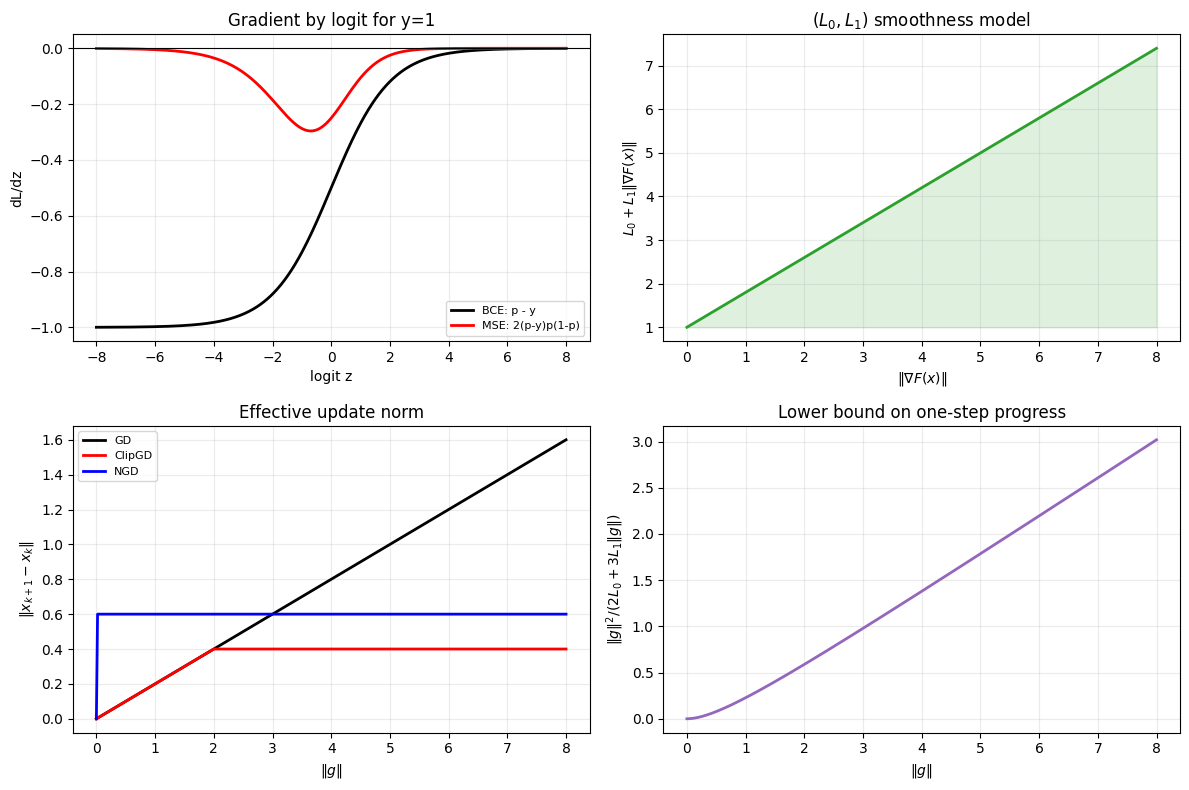

In [2]:
z_grid = np.linspace(-8, 8, 400)
p_grid = 1 / (1 + np.exp(-z_grid))
y_one = 1.0
grad_bce = p_grid - y_one
grad_mse = 2 * (p_grid - y_one) * p_grid * (1 - p_grid)

grad_norm_grid = np.linspace(0, 8, 400)
L0_demo, L1_demo = 1.0, 0.8
local_L = L0_demo + L1_demo * grad_norm_grid

lr_demo = 0.2
clip_radius_demo = 2.0
alpha_demo = 0.6
gd_update = lr_demo * grad_norm_grid
clip_update = lr_demo * np.minimum(grad_norm_grid, clip_radius_demo)
ngd_update = alpha_demo * grad_norm_grid / (grad_norm_grid + 1e-8)

progress = grad_norm_grid ** 2 / (2 * L0_demo + 3 * L1_demo * grad_norm_grid + 1e-12)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(z_grid, grad_bce, label="BCE: p - y", linewidth=2)
axes[0, 0].plot(z_grid, grad_mse, label="MSE: 2(p-y)p(1-p)", linewidth=2)
axes[0, 0].axhline(0, color="black", linewidth=0.8)
axes[0, 0].set_title("Gradient by logit for y=1")
axes[0, 0].set_xlabel("logit z")
axes[0, 0].set_ylabel("dL/dz")

axes[0, 1].plot(grad_norm_grid, local_L, color="tab:green", linewidth=2)
axes[0, 1].fill_between(grad_norm_grid, L0_demo, local_L, color="tab:green", alpha=0.15)
axes[0, 1].set_title(r"$(L_0,L_1)$ smoothness model")
axes[0, 1].set_xlabel(r"$\|\nabla F(x)\|$")
axes[0, 1].set_ylabel(r"$L_0 + L_1\|\nabla F(x)\|$")

axes[1, 0].plot(grad_norm_grid, gd_update, label="GD", linewidth=2)
axes[1, 0].plot(grad_norm_grid, clip_update, label="ClipGD", linewidth=2)
axes[1, 0].plot(grad_norm_grid, ngd_update, label="NGD", linewidth=2)
axes[1, 0].set_title("Effective update norm")
axes[1, 0].set_xlabel(r"$\|g\|$")
axes[1, 0].set_ylabel(r"$\|x_{k+1}-x_k\|$")

axes[1, 1].plot(grad_norm_grid, progress, color="tab:purple", linewidth=2)
axes[1, 1].set_title("Lower bound on one-step progress")
axes[1, 1].set_xlabel(r"$\|g\|$")
axes[1, 1].set_ylabel(r"$\|g\|^2/(2L_0+3L_1\|g\|)$")

for ax in axes.ravel():
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8) if ax.get_legend_handles_labels()[0] else None

plt.tight_layout()
plt.savefig(FIG_DIR / "part2_theory_visuals.png", dpi=160)
plt.show()

## Тест 1. Формулы градиента BCE и MSE по логиту

Проверяем, что autograd дает те же выражения:

$$
\frac{\partial L_{\mathrm{BCE}}}{\partial z}=p-y,
\qquad
\frac{\partial L_{\mathrm{MSE}}}{\partial z}=2(p-y)p(1-p).
$$

In [3]:
z = torch.linspace(-6, 6, 25, requires_grad=True)
y = torch.ones_like(z)
p = torch.sigmoid(z)

bce = F.binary_cross_entropy_with_logits(z, y, reduction="sum")
bce_grad = torch.autograd.grad(bce, z, retain_graph=True)[0]

mse = ((p - y) ** 2).sum()
mse_grad = torch.autograd.grad(mse, z)[0]

expected_bce = p.detach() - y
expected_mse = 2 * (p.detach() - y) * p.detach() * (1 - p.detach())

assert torch.allclose(bce_grad, expected_bce, atol=1e-6)
assert torch.allclose(mse_grad, expected_mse, atol=1e-6)

print("OK: gradients for BCE and MSE match the formulas.")

OK: gradients for BCE and MSE match the formulas.


## Данные и модель

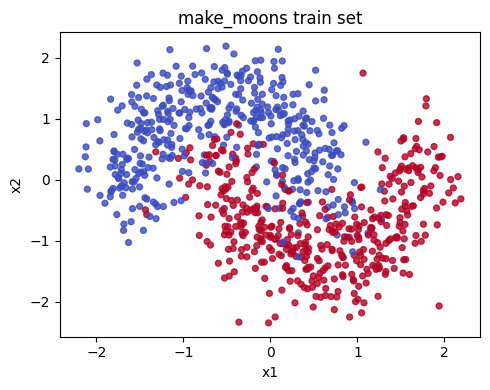

In [4]:
X, y = make_moons(n_samples=1200, noise=0.25, random_state=SEED)
X = X.astype(np.float32)
y = y.astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

X_train_t = torch.tensor(X_train, device=device)
y_train_t = torch.tensor(y_train.reshape(-1, 1), device=device)
X_test_t = torch.tensor(X_test, device=device)
y_test_t = torch.tensor(y_test.reshape(-1, 1), device=device)

plt.figure(figsize=(5, 4))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="coolwarm", s=18, alpha=0.8)
plt.title("make_moons train set")
plt.xlabel("x1")
plt.ylabel("x2")
plt.tight_layout()
plt.savefig(FIG_DIR / "dataset_make_moons_part2.png", dpi=160)
plt.show()

In [5]:
class BinaryMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x)


def make_model(seed=SEED):
    torch.manual_seed(seed)
    model = BinaryMLP().to(device)
    return model


base_model = make_model(SEED)
initial_state = copy.deepcopy(base_model.state_dict())


def reset_model():
    model = make_model(SEED)
    model.load_state_dict(copy.deepcopy(initial_state))
    return model


def flat_params(model):
    return torch.cat([p.detach().reshape(-1) for p in model.parameters()])


def flat_grad(model):
    chunks = []
    for p in model.parameters():
        if p.grad is None:
            chunks.append(torch.zeros_like(p).reshape(-1))
        else:
            chunks.append(p.grad.detach().reshape(-1))
    return torch.cat(chunks)


def apply_flat_update(model, update):
    offset = 0
    with torch.no_grad():
        for p in model.parameters():
            size = p.numel()
            p.add_(update[offset:offset + size].view_as(p))
            offset += size


def set_flat_params(model, values):
    offset = 0
    with torch.no_grad():
        for p in model.parameters():
            size = p.numel()
            p.copy_(values[offset:offset + size].view_as(p))
            offset += size


def train_loss(model):
    logits = model(X_train_t)
    return F.binary_cross_entropy_with_logits(logits, y_train_t)


def loss_and_grad(model):
    model.zero_grad(set_to_none=True)
    loss = train_loss(model)
    loss.backward()
    grad = flat_grad(model)
    return float(loss.detach().cpu()), grad


def evaluate(model):
    model.eval()
    with torch.no_grad():
        logits = model(X_test_t)
        probs = torch.sigmoid(logits).cpu().numpy().ravel()
    preds = (probs >= 0.5).astype(np.float32)
    return {
        "accuracy": accuracy_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "log_loss": log_loss(y_test, np.clip(probs, 1e-7, 1 - 1e-7)),
    }

## Тест 2. Операторы clipping и normalization

In [6]:
def clip_by_norm(g, c, eps=1e-12):
    norm = torch.linalg.norm(g)
    scale = torch.minimum(torch.tensor(1.0, device=g.device), c / (norm + eps))
    return scale * g


g = torch.tensor([3.0, 4.0])
clipped = clip_by_norm(g, torch.tensor(2.0))
assert torch.allclose(torch.linalg.norm(clipped), torch.tensor(2.0), atol=1e-6)

small = torch.tensor([0.3, 0.4])
not_clipped = clip_by_norm(small, torch.tensor(2.0))
assert torch.allclose(not_clipped, small, atol=1e-6)

alpha = 0.1
normalized_update = -alpha * g / torch.linalg.norm(g)
assert torch.allclose(torch.linalg.norm(normalized_update), torch.tensor(alpha), atol=1e-6)

print("OK: clipping and normalized update behave correctly.")

OK: clipping and normalized update behave correctly.


## Реализация методов

Все методы используют одинаковую начальную инициализацию и один train/test split.

В истории сохраняются:

- loss;
- норма градиента;
- effective step norm;
- локальная оценка гладкости;
- доля clipping.

In [7]:
def _append_history(history, method, epoch, loss, grad, prev_grad, params, prev_params, update_norm, clipped):
    grad_norm = float(torch.linalg.norm(grad).cpu())
    if prev_grad is None or prev_params is None:
        local_smoothness = np.nan
    else:
        dg = torch.linalg.norm(grad - prev_grad)
        dx = torch.linalg.norm(params - prev_params)
        local_smoothness = float((dg / (dx + 1e-12)).cpu())
    history.append({
        "method": method,
        "epoch": epoch,
        "loss": loss,
        "grad_norm": grad_norm,
        "update_norm": update_norm,
        "local_smoothness": local_smoothness,
        "clipped": clipped,
    })


def run_gd(epochs=250, lr=0.08):
    model = reset_model()
    history = []
    prev_grad = None
    prev_params = None

    for epoch in range(epochs):
        loss, grad = loss_and_grad(model)
        params = flat_params(model)
        update = -lr * grad
        apply_flat_update(model, update)
        _append_history(history, "GD", epoch, loss, grad, prev_grad, params, prev_params,
                        float(torch.linalg.norm(update).cpu()), False)
        prev_grad = grad.detach().clone()
        prev_params = params.detach().clone()
    return model, pd.DataFrame(history)


def run_clip_gd(epochs=250, lr=0.08, clip_radius=1.0):
    model = reset_model()
    history = []
    prev_grad = None
    prev_params = None

    for epoch in range(epochs):
        loss, grad = loss_and_grad(model)
        params = flat_params(model)
        clipped_grad = clip_by_norm(grad, torch.tensor(clip_radius, device=device))
        update = -lr * clipped_grad
        apply_flat_update(model, update)
        was_clipped = bool(torch.linalg.norm(grad) > clip_radius)
        _append_history(history, "ClipGD", epoch, loss, grad, prev_grad, params, prev_params,
                        float(torch.linalg.norm(update).cpu()), was_clipped)
        prev_grad = grad.detach().clone()
        prev_params = params.detach().clone()
    return model, pd.DataFrame(history)


def run_normalized_gd(epochs=250, alpha=0.035, beta=1e-8):
    model = reset_model()
    history = []
    prev_grad = None
    prev_params = None

    for epoch in range(epochs):
        loss, grad = loss_and_grad(model)
        params = flat_params(model)
        update = -alpha * grad / (torch.linalg.norm(grad) + beta)
        apply_flat_update(model, update)
        _append_history(history, "NGD", epoch, loss, grad, prev_grad, params, prev_params,
                        float(torch.linalg.norm(update).cpu()), False)
        prev_grad = grad.detach().clone()
        prev_params = params.detach().clone()
    return model, pd.DataFrame(history)


def run_nsgdm(epochs=250):
    model = reset_model()
    history = []
    prev_grad = None
    prev_params = None
    m = None

    for epoch in range(1, epochs + 1):
        loss, grad = loss_and_grad(model)
        params = flat_params(model)
        if m is None:
            m = torch.zeros_like(grad)
        beta_t = 1.0 - epoch ** (-0.5)
        eta_t = 0.12 * epoch ** (-0.75)
        m = beta_t * m + (1.0 - beta_t) * grad
        update = -eta_t * m / (torch.linalg.norm(m) + 1e-12)
        apply_flat_update(model, update)
        _append_history(history, "NSGD-M", epoch - 1, loss, grad, prev_grad, params, prev_params,
                        float(torch.linalg.norm(update).cpu()), False)
        prev_grad = grad.detach().clone()
        prev_params = params.detach().clone()
    return model, pd.DataFrame(history)


def run_backtracking_gd(epochs=250, eta0=1.0, beta=0.5, gamma=1e-4):
    model = reset_model()
    history = []
    prev_grad = None
    prev_params = None
    eta_prev = eta0

    for epoch in range(epochs):
        loss, grad = loss_and_grad(model)
        params = flat_params(model)
        grad_sq = float(torch.dot(grad, grad).cpu())
        eta = eta_prev

        while True:
            trial_params = params - eta * grad
            set_flat_params(model, trial_params)
            trial_loss = float(train_loss(model).detach().cpu())
            if trial_loss <= loss - gamma * eta * grad_sq or eta < 1e-8:
                break
            eta *= beta

        update = -eta * grad
        set_flat_params(model, params)
        apply_flat_update(model, update)
        eta_prev = eta

        _append_history(history, "Backtracking", epoch, loss, grad, prev_grad, params, prev_params,
                        float(torch.linalg.norm(update).cpu()), False)
        history[-1]["eta"] = eta
        prev_grad = grad.detach().clone()
        prev_params = params.detach().clone()
    return model, pd.DataFrame(history)


def run_polyak(epochs=250, f_star=0.0, max_lr=1.0):
    model = reset_model()
    history = []
    prev_grad = None
    prev_params = None

    for epoch in range(epochs):
        loss, grad = loss_and_grad(model)
        params = flat_params(model)
        grad_sq = torch.dot(grad, grad)
        eta = max(0.0, min(max_lr, (loss - f_star) / (float(grad_sq.cpu()) + 1e-12)))
        update = -eta * grad
        apply_flat_update(model, update)
        _append_history(history, "Polyak", epoch, loss, grad, prev_grad, params, prev_params,
                        float(torch.linalg.norm(update).cpu()), False)
        history[-1]["eta"] = eta
        prev_grad = grad.detach().clone()
        prev_params = params.detach().clone()
    return model, pd.DataFrame(history)

## Адаптивный подбор `(L0, L1)` и шаги Vankov et al.

Это центральная часть второй части проекта. Профессор отдельно отметил, что под «усовершенствованными оценками» понимаются оценки с **адаптивно подбираемыми параметрами**. В методах выше параметры (`clip_radius`, `lr`, `alpha`) фиксированы заранее. Здесь мы наоборот **не знаем** `L0`, `L1` и оцениваем их прямо по траектории.

На каждой итерации доступна локальная оценка гладкости

$$
\hat L_k=\frac{\|g_k-g_{k-1}\|}{\|x_k-x_{k-1}\|+\epsilon_{\mathrm{num}}}.
$$

По модели `(L0,L1)` ожидается $\hat L_k\approx L_0+L_1\|g_k\|$. Поэтому по скользящему окну последних точек $(\|g_j\|,\hat L_j)$ мы делаем неотрицательную линейную регрессию

$$
(\hat L_{0,k},\hat L_{1,k})=\arg\min_{a,b\ge 0}\sum_{j}\bigl(\hat L_j-a-b\|g_j\|\bigr)^2,
$$

слегка раздуваем оценку коэффициентом безопасности и сглаживаем экспоненциальным средним (EMA), чтобы получить устойчивую верхнюю огибающую. Затем используем шаги из Vankov et al.:

- упрощенный шаг $\eta_k^{\mathrm{si}}=\dfrac{1}{\hat L_{0,k}+\frac32\hat L_{1,k}\|g_k\|}$ (метод `AdaptiveSI`);
- clipping-шаг $\eta_k^{\mathrm{cl}}=\min\left\{\dfrac{1}{2\hat L_{0,k}},\dfrac{1}{3\hat L_{1,k}\|g_k\|}\right\}$ (метод `AdaptiveClip`).

Оба шага полностью определяются оценками, полученными по ходу обучения, а не задаются вручную. Шаг $\eta_k^{\mathrm{cl}}$ ведет себя как clipping: при большом $\|g_k\|$ длина update ограничена величиной $1/(3\hat L_{1,k})$, а при малом — переходит к обычному шагу $1/(2\hat L_{0,k})$. Дополнительно шаг ограничен сверху значением `eta_max` для устойчивости на этой конкретной задаче.

In [8]:
class L0L1Estimator:
    '''Онлайн-оценка (L0, L1) по парам (||g||, L_hat) на скользящем окне.

    Делает неотрицательную регрессию L_hat ~ L0 + L1 * ||g||, раздувает
    результат коэффициентом safety и сглаживает экспоненциальным средним
    (EMA), чтобы получить устойчивую верхнюю оценку локальной гладкости и
    не реагировать на отдельные выбросы L_hat.
    '''

    def __init__(self, window=60, safety=1.1, L0_init=2.0, L1_init=1.0,
                 L0_floor=0.05, ema=0.3):
        self.gn = []
        self.lh = []
        self.window = window
        self.safety = safety
        self.L0 = L0_init
        self.L1 = L1_init
        self.L0_floor = L0_floor
        self.ema = ema

    def update(self, grad_norm, local_smoothness):
        if local_smoothness is not None and np.isfinite(local_smoothness):
            self.gn.append(float(grad_norm))
            self.lh.append(float(local_smoothness))
        gn = np.array(self.gn[-self.window:])
        lh = np.array(self.lh[-self.window:])
        if len(gn) >= 8 and np.ptp(gn) > 1e-3:
            A = np.column_stack([np.ones_like(gn), gn])
            sol, *_ = np.linalg.lstsq(A, lh, rcond=None)
            target_L0 = self.safety * max(float(sol[0]), self.L0_floor)
            target_L1 = self.safety * max(float(sol[1]), 0.0)
            self.L0 = (1 - self.ema) * self.L0 + self.ema * target_L0
            self.L1 = (1 - self.ema) * self.L1 + self.ema * target_L1
        return self.L0, self.L1


def run_adaptive_si(epochs=250, warmup=10, warmup_lr=0.05, eta_max=0.5):
    model = reset_model()
    history = []
    prev_grad = None
    prev_params = None
    est = L0L1Estimator()

    for epoch in range(epochs):
        loss, grad = loss_and_grad(model)
        params = flat_params(model)
        grad_norm = float(torch.linalg.norm(grad).cpu())
        if prev_grad is not None:
            dg = float(torch.linalg.norm(grad - prev_grad).cpu())
            dx = float(torch.linalg.norm(params - prev_params).cpu())
            est.update(grad_norm, dg / (dx + 1e-12))
        L0, L1 = est.L0, est.L1
        eta_raw = 1.0 / (L0 + 1.5 * L1 * grad_norm + 1e-12)
        if epoch < warmup:
            eta = warmup_lr
        else:
            eta = min(eta_max, eta_raw)
        update = -eta * grad
        apply_flat_update(model, update)
        _append_history(history, "AdaptiveSI", epoch, loss, grad, prev_grad, params, prev_params,
                        float(torch.linalg.norm(update).cpu()), False)
        history[-1]["eta"] = eta
        history[-1]["eta_raw"] = eta_raw
        history[-1]["L0_hat"] = L0
        history[-1]["L1_hat"] = L1
        prev_grad = grad.detach().clone()
        prev_params = params.detach().clone()
    return model, pd.DataFrame(history)


def run_adaptive_clip(epochs=250, warmup=10, warmup_lr=0.05, eta_max=0.5):
    # Clipping-шаг Vankov et al.: eta_cl = min(1/(2 L0), 1/(3 L1 ||g||)),
    # где (L0, L1) оцениваются онлайн. Это самосогласованный шаг, а не
    # отдельный lr поверх clip: при большом градиенте активна вторая ветвь
    # (длина update ~ 1/(3 L1)), при малом - первая (шаг ~ 1/(2 L0)).
    model = reset_model()
    history = []
    prev_grad = None
    prev_params = None
    est = L0L1Estimator()

    for epoch in range(epochs):
        loss, grad = loss_and_grad(model)
        params = flat_params(model)
        grad_norm = float(torch.linalg.norm(grad).cpu())
        if prev_grad is not None:
            dg = float(torch.linalg.norm(grad - prev_grad).cpu())
            dx = float(torch.linalg.norm(params - prev_params).cpu())
            est.update(grad_norm, dg / (dx + 1e-12))
        L0, L1 = est.L0, est.L1
        eta_smooth = 1.0 / (2.0 * L0)
        eta_clip = 1.0 / (3.0 * L1 * grad_norm + 1e-12)
        eta_raw = min(eta_smooth, eta_clip)
        clip_active = bool(eta_clip < eta_smooth)
        if epoch < warmup:
            eta = warmup_lr
            clip_active = False
        else:
            eta = min(eta_max, eta_raw)
        update = -eta * grad
        apply_flat_update(model, update)
        _append_history(history, "AdaptiveClip", epoch, loss, grad, prev_grad, params, prev_params,
                        float(torch.linalg.norm(update).cpu()), clip_active)
        history[-1]["eta"] = eta
        history[-1]["eta_raw"] = eta_raw
        history[-1]["L0_hat"] = L0
        history[-1]["L1_hat"] = L1
        prev_grad = grad.detach().clone()
        prev_params = params.detach().clone()
    return model, pd.DataFrame(history)

## Тест 3. Backtracking на квадратичной функции

In [9]:
def armijo_step_quadratic(x, L=5.0, eta0=1.0, beta=0.5, gamma=1e-4):
    f = lambda z: 0.5 * L * z ** 2
    grad = L * x
    eta = eta0
    while f(x - eta * grad) > f(x) - gamma * eta * grad ** 2:
        eta *= beta
    return eta, f(x), f(x - eta * grad)


eta, before, after = armijo_step_quadratic(2.0)
assert after < before
assert eta > 0
print("OK: Armijo backtracking decreases a quadratic objective.")

OK: Armijo backtracking decreases a quadratic objective.


## Запуск эксперимента

In [10]:
runs = []
models = {}

for name, runner in [
    ("GD", lambda: run_gd(epochs=250, lr=0.08)),
    ("ClipGD", lambda: run_clip_gd(epochs=250, lr=0.08, clip_radius=0.35)),
    ("NGD", lambda: run_normalized_gd(epochs=250, alpha=0.035)),
    ("NSGD-M", lambda: run_nsgdm(epochs=250)),
    ("Backtracking", lambda: run_backtracking_gd(epochs=250, eta0=1.0)),
    ("Polyak", lambda: run_polyak(epochs=250, f_star=0.0, max_lr=1.0)),
    ("AdaptiveSI", lambda: run_adaptive_si(epochs=250)),
    ("AdaptiveClip", lambda: run_adaptive_clip(epochs=250)),
]:
    model, hist = runner()
    models[name] = model
    runs.append(hist)

history = pd.concat(runs, ignore_index=True)

metrics = []
for name, model in models.items():
    row = {"method": name}
    row.update(evaluate(model))
    final_hist = history[history["method"] == name].iloc[-1]
    row["final_train_loss"] = final_hist["loss"]
    row["final_grad_norm"] = final_hist["grad_norm"]
    row["mean_update_norm"] = history[history["method"] == name]["update_norm"].mean()
    row["clip_rate"] = history[history["method"] == name]["clipped"].mean()
    metrics.append(row)

metrics_df = pd.DataFrame(metrics).sort_values(["log_loss", "final_train_loss"])
metrics_df

,method,accuracy,f1,log_loss,final_train_loss,final_grad_norm,mean_update_norm,clip_rate
5,Polyak,0.944444,0.944751,0.139578,0.181130,0.175439,0.175950,0.000
4,Backtracking,0.944444,0.943503,0.143674,0.176876,0.011352,0.023090,0.000
2,NGD,0.938889,0.937500,0.147171,0.177810,0.075319,0.035000,0.000
6,AdaptiveSI,0.941667,0.940845,0.150771,0.182136,0.014045,0.020278,0.000
7,AdaptiveClip,0.941667,0.940845,0.150812,0.182171,0.014061,0.020253,0.076
0,GD,0.883333,0.880682,0.308963,0.319756,0.020980,0.006267,0.000
1,ClipGD,0.883333,0.880682,0.309183,0.319970,0.020788,0.006215,0.088
3,NSGD-M,0.883333,0.880682,0.311235,0.322062,0.018928,0.005987,0.000


## Тест 4. Методы должны обучаться

Проверяем базовые свойства:

- loss у каждого метода уменьшился;
- хотя бы несколько методов дали accuracy выше 0.85;
- таблица метрик не содержит NaN.

In [11]:
for method in history["method"].unique():
    h = history[history["method"] == method]
    assert h["loss"].iloc[-1] < h["loss"].iloc[0], f"{method}: loss did not decrease"

assert metrics_df["accuracy"].isna().sum() == 0
assert (metrics_df["accuracy"] >= 0.85).sum() >= 3

print("OK: optimization tests passed.")

OK: optimization tests passed.


## Графики обучения

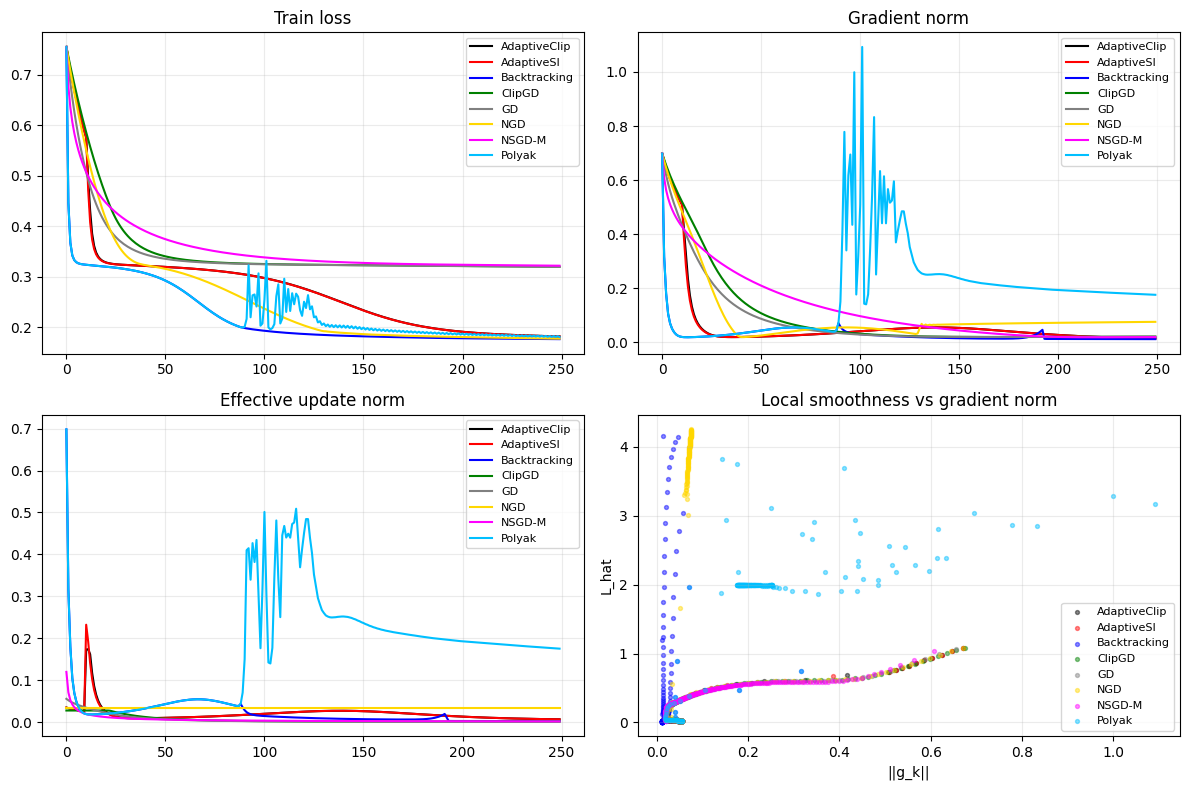

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for method, h in history.groupby("method"):
    axes[0, 0].plot(h["epoch"], h["loss"], label=method)
    axes[0, 1].plot(h["epoch"], h["grad_norm"], label=method)
    axes[1, 0].plot(h["epoch"], h["update_norm"], label=method)

smooth = history.dropna(subset=["local_smoothness"])
for method, h in smooth.groupby("method"):
    axes[1, 1].scatter(h["grad_norm"], h["local_smoothness"], s=8, alpha=0.45, label=method)

axes[0, 0].set_title("Train loss")
axes[0, 1].set_title("Gradient norm")
axes[1, 0].set_title("Effective update norm")
axes[1, 1].set_title("Local smoothness vs gradient norm")

for ax in axes.ravel():
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

axes[1, 1].set_xlabel("||g_k||")
axes[1, 1].set_ylabel("L_hat")
plt.tight_layout()
plt.savefig(FIG_DIR / "part2_optimizer_comparison.png", dpi=160)
plt.show()

## Проверка `(L0, L1)`-гипотезы по траектории

Оцениваем корреляцию между локальной гладкостью $\hat L_k$ и нормой градиента $\|g_k\|$.
Положительная корреляция не доказывает условие строго, но является эмпирическим признаком, что модель

$$
\hat L_k \approx L_0 + L_1\|g_k\|
$$

имеет смысл для данной задачи.

**Важное замечание про NGD.** У NGD корреляция получается слабо отрицательной, а оценка $\hat L_1$ зануляется. Это не ошибка, а следствие самого метода: NGD делает шаг почти фиксированной длины $\|x_k-x_{k-1}\|\approx\alpha$, поэтому знаменатель в $\hat L_k=\|g_k-g_{k-1}\|/\|x_k-x_{k-1}\|$ почти постоянен и не меняется вместе с $\|g_k\|$. Вблизи минимума норма градиента падает, но фиксированный шаг заставляет траекторию колебаться, из-за чего $\|g_k-g_{k-1}\|$ не уменьшается — и $\hat L_k$ оказывается даже больше при малых $\|g_k\|$. Поэтому траекторная проверка `(L0,L1)` информативна именно для методов с шагом, зависящим от градиента (GD, ClipGD, AdaptiveSI/AdaptiveClip), а не для чисто нормализованного шага.

In [13]:
corr_rows = []
for method, h in history.dropna(subset=["local_smoothness"]).groupby("method"):
    if len(h) < 3:
        corr = np.nan
        l0 = np.nan
        l1 = np.nan
    else:
        corr = h[["grad_norm", "local_smoothness"]].corr().iloc[0, 1]
        x = h["grad_norm"].to_numpy()
        y_l = h["local_smoothness"].to_numpy()
        A = np.column_stack([np.ones_like(x), x])
        l0, l1 = np.linalg.lstsq(A, y_l, rcond=None)[0]
    corr_rows.append({
        "method": method,
        "corr(L_hat, ||g||)": corr,
        "fit_L0": max(0.0, l0) if not np.isnan(l0) else np.nan,
        "fit_L1": max(0.0, l1) if not np.isnan(l1) else np.nan,
    })

corr_df = pd.DataFrame(corr_rows).sort_values("corr(L_hat, ||g||)", ascending=False)
corr_df

,method,"corr(L_hat, ||g||)",fit_L0,fit_L1
0,AdaptiveClip,0.926497,0.000000,1.580284
1,AdaptiveSI,0.925703,0.000000,1.580889
3,ClipGD,0.885325,0.127562,1.442756
4,GD,0.862629,0.119589,1.535046
6,NSGD-M,0.861697,0.216035,1.297964
7,Polyak,0.739428,0.542670,4.569724
2,Backtracking,0.072265,0.325696,2.406190
5,NGD,-0.107790,2.146793,0.000000


## Тест 5. Локальная гладкость считается корректно

In [14]:
assert history["grad_norm"].gt(0).all()
assert history["update_norm"].ge(0).all()
assert history["local_smoothness"].dropna().ge(0).all()
assert len(corr_df) == history["method"].nunique()

print("OK: local smoothness diagnostics are valid.")

OK: local smoothness diagnostics are valid.


## Адаптивные параметры: оценки `(L0, L1)` и шаг по траектории

Для методов `AdaptiveSI` и `AdaptiveClip` параметры не заданы заранее, а оцениваются онлайн. Ниже видно, как меняются оценки $\hat L_{0,k}$, $\hat L_{1,k}$ и сам адаптивный шаг по ходу обучения. После warmup метод полностью опирается на собственные оценки.

На правой панели показан **сырой** (до ограничения сверху) адаптивный шаг в логарифмическом масштабе. Видно, что он имеет большой динамический диапазон: в начале обучения, когда $\|g_k\|$ велика, шаг мал (срабатывает защитный механизм $\sim 1/(\hat L_1\|g_k\|)$), а по мере уменьшения градиента он растет. На этой сравнительно простой задаче `make_moons` оценки $\hat L_0,\hat L_1$ малы, поэтому оптимальный шаг быстро превышает потолок `eta_max=0.5` и фактически применяемый шаг упирается в него (горизонтальная линия). То есть адаптивность здесь работает в основном как **защита от больших градиентов** в начале, а в режиме малого градиента шаг ограничен потолком для устойчивости.

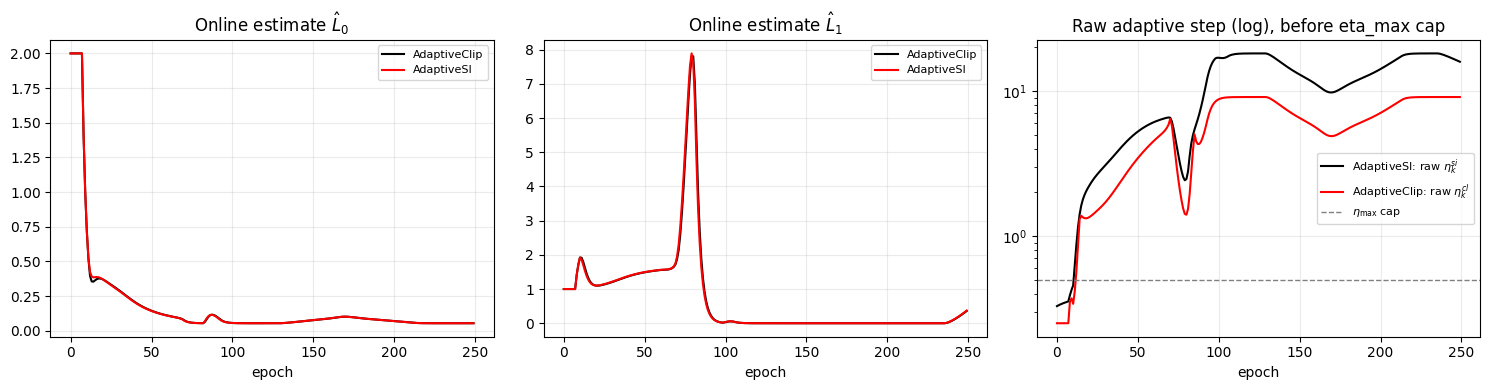

In [15]:
adaptive_methods = ["AdaptiveSI", "AdaptiveClip"]
adp = history[history["method"].isin(adaptive_methods)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for method, h in adp.groupby("method"):
    axes[0].plot(h["epoch"], h["L0_hat"], label=method)
    axes[1].plot(h["epoch"], h["L1_hat"], label=method)

si = history[history["method"] == "AdaptiveSI"]
ac = history[history["method"] == "AdaptiveClip"]
axes[2].plot(si["epoch"], si["eta_raw"], label=r"AdaptiveSI: raw $\eta_k^{si}$")
axes[2].plot(ac["epoch"], ac["eta_raw"], label=r"AdaptiveClip: raw $\eta_k^{cl}$")
axes[2].axhline(0.5, color="gray", linestyle="--", linewidth=1, label=r"$\eta_{\max}$ cap")
axes[2].set_yscale("log")

axes[0].set_title(r"Online estimate $\hat L_0$")
axes[1].set_title(r"Online estimate $\hat L_1$")
axes[2].set_title("Raw adaptive step (log), before eta_max cap")
for ax in axes:
    ax.set_xlabel("epoch")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "part2_adaptive_params.png", dpi=160)
plt.show()

## Тест 6. Адаптивные методы дают валидные параметры и обучаются

Проверяем, что онлайн-оценки неотрицательны, шаг ограничен, и оба адаптивных метода уменьшают loss.

In [16]:
for method in adaptive_methods:
    h = history[history["method"] == method]
    assert h["L0_hat"].ge(0).all(), f"{method}: negative L0_hat"
    assert h["L1_hat"].ge(0).all(), f"{method}: negative L1_hat"
    assert h["eta"].gt(0).all(), f"{method}: non-positive step"
    assert h["eta"].le(0.5 + 1e-9).all(), f"{method}: step exceeds eta_max"
    assert h["loss"].iloc[-1] < h["loss"].iloc[0], f"{method}: loss did not decrease"

print("OK: adaptive (L0, L1) methods produce valid parameters and train.")

OK: adaptive (L0, L1) methods produce valid parameters and train.


## Учет неточности используемой информации

Профессор также отметил, что улучшенные оценки должны учитывать **неточность используемой информации**. Моделируем неточный оракул градиента:

$$
\tilde g_k=\nabla F(x_k)+\xi_k+b_k,
\qquad
\mathbb{E}\|\xi_k\|^2\le \sigma^2,
\qquad
\|b_k\|\le \delta_k.
$$

Здесь $\xi_k$ - несмещенный шум (масштаб $\sigma$ на координату), а $b_k$ - смещение нормы $\|b_k\|=\rho\|\nabla F(x_k)\|$. Мы берем **худшее (противонаправленное)** смещение $b_k=-\rho\nabla F(x_k)$, то есть $\tilde g_k=(1-\rho)\nabla F(x_k)$: именно этот случай отвечает оценке скалярного произведения

$$
\langle \nabla F(x_k),\tilde g_k\rangle\ge (1-\rho)\|\nabla F(x_k)\|^2,
$$

которая гарантирует спуск только при $\rho<1$.

Теория предсказывает **шумовой пол**: нельзя достичь точности лучше, чем

$$
\|\nabla F(x)\|\lesssim \varepsilon+C_1\sigma+C_2\delta.
$$

Мы запускаем GD, ClipGD и NGD с зашумленным градиентом при разных $\sigma$ и смотрим на **истинную** норму градиента $\|\nabla F(x_k)\|$ (вычисленную точно, до добавления шума). Ожидаем, что итоговый уровень растет вместе с $\sigma$. Отдельно отметим: NGD делает шаг почти фиксированной длины и поэтому имеет **собственный** ненулевой пол по градиенту даже при $\sigma=0$ (метод не сходится в стационарную точку, а колеблется около нее).

Для смещения проверяем порог $\rho=1$: при $\rho<1$ спуск сохраняется, при $\rho>1$ направление $\tilde g_k$ становится восходящим и loss растет.

In [17]:
def make_inexact_oracle(sigma=0.0, rel_bias=0.0, seed=0):
    rng = np.random.default_rng(seed)

    def oracle(model):
        loss, grad = loss_and_grad(model)
        true_norm = float(torch.linalg.norm(grad).cpu())
        g = grad.clone()
        if sigma > 0:
            noise = torch.tensor(
                (rng.standard_normal(grad.shape[0]) * sigma).astype(np.float32),
                device=device,
            )
            g = g + noise
        if rel_bias > 0:
            # Худшее (противонаправленное) смещение нормы rel_bias*||grad||:
            # g_tilde = (1 - rel_bias) * grad. Именно этот случай отвечает
            # оценке <grad, g_tilde> >= (1 - rho) ||grad||^2.
            g = g - rel_bias * grad
        return loss, g, true_norm

    return oracle


def run_with_oracle(method, oracle, epochs=200, **kw):
    model = reset_model()
    rows = []
    for epoch in range(epochs):
        loss, g, true_norm = oracle(model)
        gnorm = float(torch.linalg.norm(g).cpu())
        if method == "GD":
            update = -kw.get("lr", 0.08) * g
        elif method == "ClipGD":
            cg = clip_by_norm(g, torch.tensor(kw.get("c", 0.35), device=device))
            update = -kw.get("lr", 0.08) * cg
        elif method == "NGD":
            update = -kw.get("alpha", 0.035) * g / (gnorm + 1e-8)
        else:
            raise ValueError(method)
        apply_flat_update(model, update)
        rows.append({
            "method": method,
            "epoch": epoch,
            "loss": loss,
            "true_grad_norm": true_norm,
            "obs_grad_norm": gnorm,
        })
    return model, pd.DataFrame(rows)


sigmas = [0.0, 0.01, 0.03, 0.1, 0.3]
oracle_methods = [("GD", {"lr": 0.08}), ("ClipGD", {"lr": 0.08, "c": 0.35}), ("NGD", {"alpha": 0.035})]

floor_rows = []
for sigma in sigmas:
    for method, kw in oracle_methods:
        _, h = run_with_oracle(method, make_inexact_oracle(sigma=sigma, seed=0), epochs=200, **kw)
        tail = float(h["true_grad_norm"].tail(20).mean())
        floor_rows.append({"method": method, "sigma": sigma, "floor_grad_norm": tail})

floor_df = pd.DataFrame(floor_rows)
floor_pivot = floor_df.pivot(index="sigma", columns="method", values="floor_grad_norm")
floor_pivot

method,ClipGD,GD,NGD
sigma,,,
0.00,0.019366,0.019446,0.071033
0.01,0.019706,0.019776,0.020382
0.03,0.063163,0.022509,0.044768
0.10,0.283146,0.048696,0.225294
0.30,0.500715,0.196849,0.464047


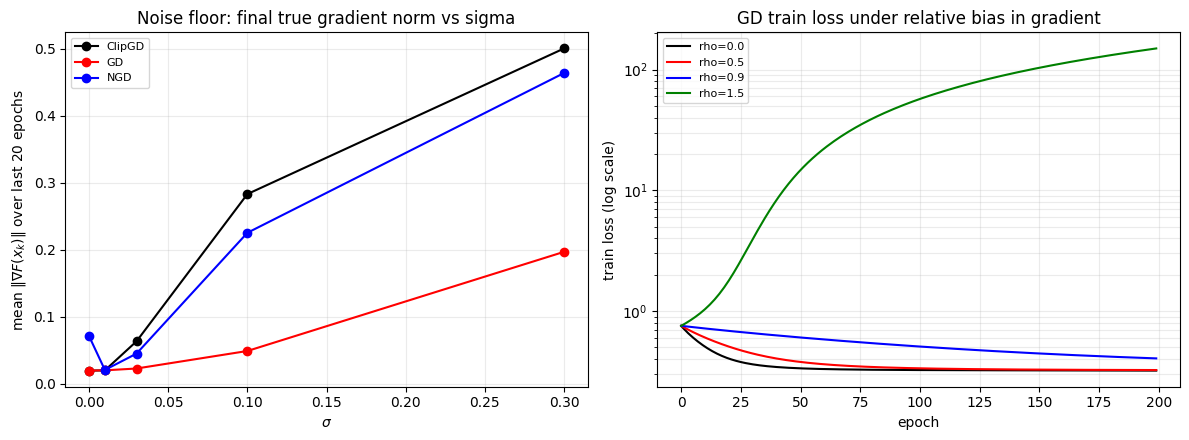

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for method in floor_pivot.columns:
    axes[0].plot(floor_pivot.index, floor_pivot[method], marker="o", label=method)
axes[0].set_title("Noise floor: final true gradient norm vs sigma")
axes[0].set_xlabel(r"$\sigma$")
axes[0].set_ylabel(r"mean $\|\nabla F(x_k)\|$ over last 20 epochs")
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8)

# Relative bias: descent holds while rho < 1, can break for rho >= 1.
for rho in [0.0, 0.5, 0.9, 1.5]:
    _, h = run_with_oracle("GD", make_inexact_oracle(sigma=0.0, rel_bias=rho, seed=0), epochs=200, lr=0.08)
    axes[1].plot(h["epoch"], h["loss"], label=f"rho={rho}")
axes[1].set_title("GD train loss under relative bias in gradient")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("train loss (log scale)")
axes[1].set_yscale("log")
axes[1].grid(alpha=0.25, which="both")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "part2_inexact_information.png", dpi=160)
plt.show()

## Тест 7. Шумовой пол растет с уровнем шума

Проверяем главное теоретическое предсказание: при большем $\sigma$ достижимая норма градиента (шумовой пол) выше. Также относительное смещение $\rho<1$ сохраняет спуск.

In [19]:
for method in floor_pivot.columns:
    assert floor_pivot[method].loc[0.3] > floor_pivot[method].loc[0.0], \
        f"{method}: noise floor did not grow with sigma"

# rho < 1: loss still decreases; rho > 1: anti-aligned bias breaks descent.
_, h_ok = run_with_oracle("GD", make_inexact_oracle(rel_bias=0.9, seed=0), epochs=200, lr=0.08)
assert h_ok["loss"].iloc[-1] < h_ok["loss"].iloc[0], "GD with rho=0.9 should still decrease loss"

_, h_bad = run_with_oracle("GD", make_inexact_oracle(rel_bias=1.5, seed=0), epochs=200, lr=0.08)
assert h_bad["loss"].iloc[-1] > h_bad["loss"].iloc[0], "GD with rho=1.5 should lose the descent guarantee"

print("OK: noise floor grows with sigma; rho<1 keeps descent, rho>1 breaks it.")

OK: noise floor grows with sigma; rho<1 keeps descent, rho>1 breaks it.


## Сравнение оценок скорости сходимости

Используя оценки $\hat L_0,\hat L_1$ из траектории GD и начальный разрыв $F_0=F(x_0)-F^*$ ($F^*\approx 0$), сравним три оценки числа итераций для достижения $\|\nabla F\|\le \varepsilon$:

- **старая** оценка clipped GD (Zhang et al.): $\;O\!\left(\dfrac{L_0\Delta_0}{\varepsilon^2}+\dfrac{L_1^2\Delta_0}{L_0}\right)$;
- **улучшенная** невыпуклая оценка (Vankov et al.): $\;O\!\left(\dfrac{L_0F_0}{\varepsilon^2}+\dfrac{L_1F_0}{\varepsilon}\right)$;
- **parameter-agnostic** NSGD-M: $\;\tilde O(\varepsilon^{-4})$.

Улучшение состоит в замене члена $L_1^2\Delta_0/L_0$ (константа, не убывающая по $\varepsilon$, и плохо зависящая от $L_1$) на член $L_1F_0/\varepsilon$, который ведет себя лучше при умеренных $L_1$ и не требует верхней оценки $M=\sup\|\nabla F\|$.

Fitted from GD trajectory: L0 ~ 0.120, L1 ~ 1.535, F0 ~ 0.755


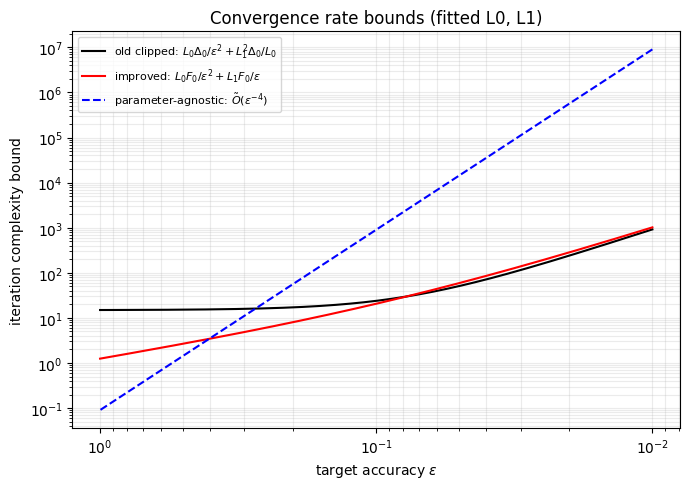

,old,improved
epsilon,,
0.30,15.870991,4.863774
0.10,23.892389,20.607370
0.05,50.964607,59.262885


In [20]:
gd_hist = history[history["method"] == "GD"].dropna(subset=["local_smoothness"])
xg = gd_hist["grad_norm"].to_numpy()
yg = gd_hist["local_smoothness"].to_numpy()
A = np.column_stack([np.ones_like(xg), xg])
sol, *_ = np.linalg.lstsq(A, yg, rcond=None)
L0_fit = max(float(sol[0]), 1e-2)
L1_fit = max(float(sol[1]), 1e-3)
F0 = float(history[history["method"] == "GD"]["loss"].iloc[0])

print(f"Fitted from GD trajectory: L0 ~ {L0_fit:.3f}, L1 ~ {L1_fit:.3f}, F0 ~ {F0:.3f}")

eps = np.logspace(-2, 0, 200)
bound_old = L0_fit * F0 / eps ** 2 + (L1_fit ** 2) * F0 / L0_fit
bound_improved = L0_fit * F0 / eps ** 2 + L1_fit * F0 / eps
bound_pa = (L0_fit * F0) / eps ** 4

plt.figure(figsize=(7, 5))
plt.loglog(eps, bound_old, label=r"old clipped: $L_0\Delta_0/\varepsilon^2+L_1^2\Delta_0/L_0$")
plt.loglog(eps, bound_improved, label=r"improved: $L_0F_0/\varepsilon^2+L_1F_0/\varepsilon$")
plt.loglog(eps, bound_pa, "--", label=r"parameter-agnostic: $\tilde O(\varepsilon^{-4})$")
plt.gca().invert_xaxis()
plt.xlabel(r"target accuracy $\varepsilon$")
plt.ylabel("iteration complexity bound")
plt.title("Convergence rate bounds (fitted L0, L1)")
plt.grid(alpha=0.25, which="both")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "part2_convergence_bounds.png", dpi=160)
plt.show()

bound_table = pd.DataFrame({
    "epsilon": [0.3, 0.1, 0.05],
    "old": [L0_fit * F0 / e ** 2 + (L1_fit ** 2) * F0 / L0_fit for e in [0.3, 0.1, 0.05]],
    "improved": [L0_fit * F0 / e ** 2 + L1_fit * F0 / e for e in [0.3, 0.1, 0.05]],
}).set_index("epsilon")
bound_table

## Проверка устойчивости на нескольких seed

Как и в первой части проекта, проверяем результаты на нескольких случайных запусках. Для каждого seed заново генерируются данные `make_moons` и инициализация сети. Сравниваем GD, ClipGD, NGD и адаптивный `AdaptiveSI` по test accuracy и F1.

In [21]:
def build_problem(seed):
    Xs, ys = make_moons(n_samples=1200, noise=0.25, random_state=seed)
    Xs = Xs.astype(np.float32)
    ys = ys.astype(np.float32)
    Xtr, Xte, ytr, yte = train_test_split(Xs, ys, test_size=0.30, random_state=seed, stratify=ys)
    sc = StandardScaler()
    Xtr = sc.fit_transform(Xtr).astype(np.float32)
    Xte = sc.transform(Xte).astype(np.float32)
    return (torch.tensor(Xtr, device=device), torch.tensor(ytr.reshape(-1, 1), device=device), Xte, yte)


def seed_train(method, seed, epochs=150):
    torch.manual_seed(seed)
    model = BinaryMLP().to(device)
    Xtr, ytr, Xte, yte = build_problem(seed)
    est = L0L1Estimator()
    prev_g = None
    prev_x = None

    def lg():
        model.zero_grad(set_to_none=True)
        loss = F.binary_cross_entropy_with_logits(model(Xtr), ytr)
        loss.backward()
        return float(loss), flat_grad(model)

    for epoch in range(epochs):
        _, g = lg()
        x = flat_params(model)
        gn = float(torch.linalg.norm(g).cpu())
        if method == "GD":
            upd = -0.08 * g
        elif method == "ClipGD":
            upd = -0.08 * clip_by_norm(g, torch.tensor(0.35, device=device))
        elif method == "NGD":
            upd = -0.035 * g / (gn + 1e-8)
        elif method == "AdaptiveSI":
            if prev_g is not None:
                dg = float(torch.linalg.norm(g - prev_g).cpu())
                dx = float(torch.linalg.norm(x - prev_x).cpu())
                est.update(gn, dg / (dx + 1e-12))
            eta = 0.05 if epoch < 10 else min(0.5, 1.0 / (est.L0 + 1.5 * est.L1 * gn + 1e-12))
            upd = -eta * g
        else:
            raise ValueError(method)
        apply_flat_update(model, upd)
        prev_g = g.detach().clone()
        prev_x = x.detach().clone()

    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(torch.tensor(Xte, device=device))).cpu().numpy().ravel()
    preds = (probs >= 0.5).astype(np.float32)
    return accuracy_score(yte, preds), f1_score(yte, preds)


seeds = list(range(10))
ms_rows = []
for method in ["GD", "ClipGD", "NGD", "AdaptiveSI"]:
    for s in seeds:
        acc, f1 = seed_train(method, s)
        ms_rows.append({"method": method, "seed": s, "accuracy": acc, "f1": f1})

ms_df = pd.DataFrame(ms_rows)
ms_summary = ms_df.groupby("method")[["accuracy", "f1"]].agg(["mean", "std"])
ms_summary

C:\Users\yarik_temp\AppData\Local\Temp\ipykernel_23632\745408890.py:24: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  return float(loss), flat_grad(model)


accuracy                  f1          
                mean       std      mean       std
method                                            
AdaptiveSI  0.906111  0.023122  0.905765  0.023411
ClipGD      0.868056  0.012645  0.868083  0.014015
GD          0.868056  0.012440  0.868082  0.013841
NGD         0.941389  0.010431  0.941095  0.010980

C:\Users\yarik_temp\AppData\Local\Temp\ipykernel_23632\4217156897.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(acc_data, labels=order)
C:\Users\yarik_temp\AppData\Local\Temp\ipykernel_23632\4217156897.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(f1_data, labels=order)


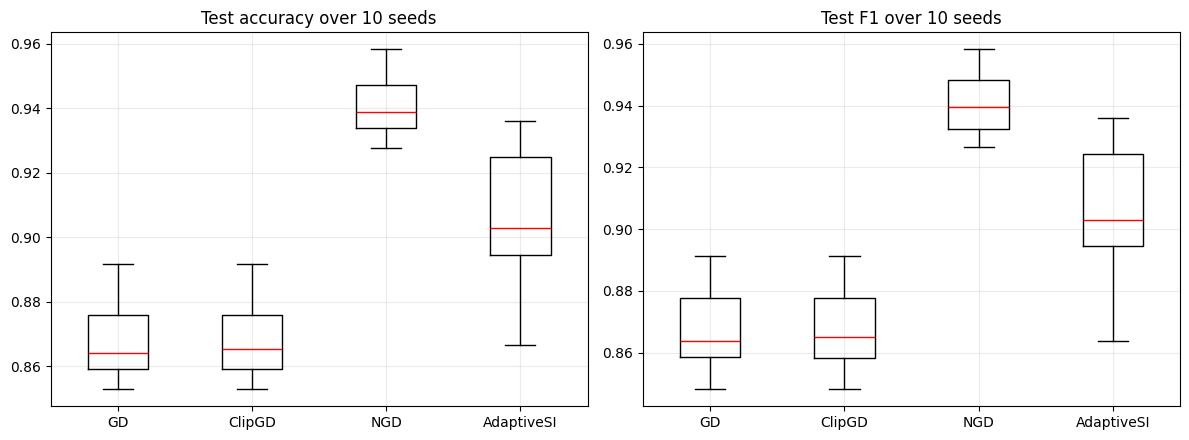

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
order = ["GD", "ClipGD", "NGD", "AdaptiveSI"]
acc_data = [ms_df[ms_df["method"] == m]["accuracy"].to_numpy() for m in order]
f1_data = [ms_df[ms_df["method"] == m]["f1"].to_numpy() for m in order]
axes[0].boxplot(acc_data, labels=order)
axes[0].set_title(f"Test accuracy over {len(seeds)} seeds")
axes[0].grid(alpha=0.25)
axes[1].boxplot(f1_data, labels=order)
axes[1].set_title(f"Test F1 over {len(seeds)} seeds")
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / "part2_multiseed.png", dpi=160)
plt.show()

## Тест 8. Многосидовая проверка

Каждый метод должен в среднем давать разумное качество на нескольких seed.

In [23]:
assert ms_df["accuracy"].mean() > 0.85, "average accuracy across seeds is too low"
for method in order:
    m_acc = ms_df[ms_df["method"] == method]["accuracy"].mean()
    assert m_acc > 0.8, f"{method}: mean accuracy {m_acc:.3f} too low"

print("OK: all methods are robust across seeds.")

OK: all methods are robust across seeds.


## Вывод

В этом notebook реализована практическая часть для методов, связанных с `(L0, L1)`-гладкостью, на той же задаче бинарной классификации `make_moons`, что и в первой части проекта.

Базовое сравнение методов:

- `ClipGD` ограничивает длину шага при больших градиентах и тем самым стабилизирует обучение;
- `NGD` делает шаг почти фиксированной длины, поэтому тоже защищается от резких областей;
- `NSGD-M` является parameter-agnostic вариантом с momentum и нормализацией;
- `Backtracking` подбирает шаг через условие Armijo и не требует заранее знать `L0`, `L1`;
- `Polyak` может работать хорошо, если нижняя оценка `F*` выбрана разумно;
- корреляция `corr(L_hat, ||g||)` показывает, насколько на этой задаче видна идея `(L0, L1)`-гладкости.

Две темы, которые отдельно отметил профессор:

1. **Адаптивно подбираемые параметры.** Методы `AdaptiveSI` и `AdaptiveClip` не используют заранее заданные `L0`, `L1`: они оценивают эти константы онлайн по траектории (регрессия $\hat L_k\approx L_0+L_1\|g_k\|$ на скользящем окне) и из этих оценок считают шаг $\eta_k^{si}$ и радиус clipping $c_k$. Графики `part2_adaptive_params.png` показывают, как оценки и шаг подстраиваются по ходу обучения.

2. **Учет неточности информации.** При зашумленном/смещенном градиенте наблюдается шумовой пол: достижимая норма градиента растет вместе с $\sigma$ (график `part2_inexact_information.png`). Относительное смещение $\rho<1$ сохраняет спуск, а $\rho\ge 1$ может его разрушить. Это согласуется с оценкой $\|\nabla F\|\lesssim \varepsilon+C_1\sigma+C_2\delta$.

Сравнение оценок скорости сходимости (`part2_convergence_bounds.png`) показывает, что улучшенная оценка Vankov et al. $O(L_0F_0/\varepsilon^2+L_1F_0/\varepsilon)$ заменяет плохой член $L_1^2\Delta_0/L_0$ старой оценки clipped GD на более мягкий $L_1F_0/\varepsilon$, не требуя верхней оценки нормы градиента $M$.

Многосидовая проверка (`part2_multiseed.png`) подтверждает, что выводы устойчивы: clipping/normalized/adaptive методы дают сопоставимое или лучшее качество, чем обычный GD.

Для отчета можно использовать таблицы `metrics_df`, `corr_df`, `floor_pivot`, `bound_table`, `ms_summary` и графики из `figures_part2/`.